In [4]:
from google.colab import files
uploaded = files.upload()


Saving phm_test.csv to phm_test (1).csv
Saving phm_train.csv to phm_train (1).csv


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk
import re
import torch
import torch.nn as nn
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from collections import Counter
from torch.utils.data import Dataset, DataLoader

# 1. Load the data
train_df = pd.read_csv('phm_train.csv')
test_df = pd.read_csv('phm_test.csv')

# 2. Basic Preprocessing Function
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_tweet(text):
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # remove urls
    text = re.sub(r'[^A-Za-z\s]', '', text) # remove non alphabets
    text = text.lower() # lowercase
    # remove stopwords
    tokens = [w for w in text.split() if w not in stop_words]
    return " ".join(tokens)

train_df['clean_tweet'] = train_df['tweet'].apply(clean_tweet)
test_df['clean_tweet'] = test_df['tweet'].apply(clean_tweet)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [6]:
import torch
from torch.utils.data import Dataset, DataLoader
from collections import Counter # Added import for Counter

# Vocabulary Building
vocab_size = 5000

# Build vocabulary from training data
all_words = []
for tweet in train_df['clean_tweet']:
    all_words.extend(tweet.split())

# Count word frequencies
word_counts = Counter(all_words)

# Get most common words up to vocab_size - 1 (for OOV token)
most_common_words = [word for word, _ in word_counts.most_common(vocab_size - 1)]

# Create word to index mapping
word_to_index = {'<PAD>': 0, '<OOV>': 1} # Reserve 0 for padding, 1 for OOV
for i, word in enumerate(most_common_words):
    word_to_index[word] = i + 2 # Start indexing from 2

# Create index to word mapping
index_to_word = {v: k for k, v in word_to_index.items()}

def text_to_sequences(texts, word_to_index, oov_token_idx=1):
    sequences = []
    for text in texts:
        seq = []
        for word in text.split():
            seq.append(word_to_index.get(word, oov_token_idx))
        sequences.append(seq)
    return sequences

def pad_sequences_pytorch(sequences, max_len, padding_value=0):
    padded_sequences = []
    for seq in sequences:
        if len(seq) < max_len:
            padded_seq = seq + [padding_value] * (max_len - len(seq))
        else:
            padded_seq = seq[:max_len]
        padded_sequences.append(padded_seq)
    return torch.tensor(padded_sequences, dtype=torch.long)

# Convert to sequences
train_seq = text_to_sequences(train_df['clean_tweet'], word_to_index)
test_seq = text_to_sequences(test_df['clean_tweet'], word_to_index)

# Padding (making all tweets the same length)
max_length = 50
train_padded = pad_sequences_pytorch(train_seq, max_length)
test_padded = pad_sequences_pytorch(test_seq, max_length)

X_train, y_train = train_padded, torch.tensor(train_df['label'].values, dtype=torch.float32)
X_test, y_test = test_padded, torch.tensor(test_df['label'].values, dtype=torch.float32)

print(f"Training data shape: {X_train.shape}, {y_train.shape}")
print(f"Test data shape: {X_test.shape}, {y_test.shape}")

Training data shape: torch.Size([9991, 50]), torch.Size([9991])
Test data shape: torch.Size([3331, 50]), torch.Size([3331])


In [7]:
import torch.nn as nn

class BiLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers, bidirectional, dropout, pad_idx):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embedding_dim,
                           hidden_dim,
                           num_layers=n_layers,
                           bidirectional=bidirectional,
                           dropout=dropout,
                           batch_first=True)
        self.fc = nn.Linear(hidden_dim * 2 if bidirectional else hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

def forward(self, text):
    # text shape: [batch_size, seq_len]

    # 1. Create a mask for non pad tokens (assuming 0 is my pad_idx)
    lengths = (text != 0).sum(dim=1).cpu()

    embedded = self.dropout(self.embedding(text))

    # 2. Pack the sequences so LSTM ignores padding
    packed_embedded = nn.utils.rnn.pack_padded_sequence(
        embedded, lengths, batch_first=True, enforce_sorted=False
    )

    packed_output, (hidden, cell) = self.lstm(packed_embedded)

    # 3. Use the hidden state as before
    if self.lstm.bidirectional:
        hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
    else:
        hidden = hidden[-1,:,:]

    hidden = self.dropout(hidden)
    intermediate = self.relu(self.fc1(hidden))
    return self.fc2(intermediate)

# Hyperparameters
EMBEDDING_DIM = 100 # Can be tuned
HIDDEN_DIM = 128    # Can be tuned
OUTPUT_DIM = 1      # Binary classification
N_LAYERS = 2        # Can be tuned
BIDIRECTIONAL = True
DROPOUT = 0.5       # Can be tuned
PAD_IDX = word_to_index['<PAD>'] # Index of the padding token

# Initialize the model
model = BiLSTM(len(word_to_index), EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM, N_LAYERS, BIDIRECTIONAL, DROPOUT, PAD_IDX)

# Print model summary
print(model)

BiLSTM(
  (embedding): Embedding(5001, 100, padding_idx=0)
  (lstm): LSTM(100, 128, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (fc): Linear(in_features=256, out_features=1, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


In [8]:
class TweetDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

# Create Dataset instances
train_dataset = TweetDataset(X_train, y_train)
test_dataset = TweetDataset(X_test, y_test)

# Define batch size
BATCH_SIZE = 64 # Can be tuned

# Create DataLoader instances
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of test batches: {len(test_loader)}")

Number of training batches: 157
Number of test batches: 53


In [9]:
import torch.optim as optim
import torch.nn as nn

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device) # Move model to GPU if available

# Optimizer and Loss Function
optimizer = optim.Adam(model.parameters()) # Adam optimizer
criterion = nn.BCEWithLogitsLoss() # Binary Cross-Entropy with Logits Loss

# Function to calculate accuracy
def binary_accuracy(preds, y):
    # Round predictions to the closest integer (0 or 1)
    rounded_preds = torch.round(torch.sigmoid(preds))
    correct = (rounded_preds == y).float() # Convert to float for division
    acc = correct.sum() / len(correct)
    return acc

# Training Function
def train(model, iterator, optimizer, criterion):
    epoch_loss = 0
    epoch_acc = 0

    model.train() # Set model to training mode

    for batch in iterator:
        text, labels = batch
        text = text.to(device)
        labels = labels.to(device)

        optimizer.zero_grad() # Clear gradients

        predictions = model(text).squeeze(1)

        loss = criterion(predictions, labels)

        acc = binary_accuracy(predictions, labels)

        loss.backward() # Backpropagate error

        optimizer.step() # Update model parameters

        epoch_loss += loss.item()
        epoch_acc += acc.item()

    return epoch_loss / len(iterator), epoch_acc / len(iterator)

In [10]:
def evaluate(model, iterator, criterion):
    epoch_loss = 0
    epoch_acc = 0

    model.eval() # Set model to evaluation mode

    with torch.no_grad(): # Disable gradient calculation
        for batch in iterator:
            text, labels = batch
            text = text.to(device)
            labels = labels.to(device)

            predictions = model(text).squeeze(1)

            loss = criterion(predictions, labels)

            acc = binary_accuracy(predictions, labels)

            epoch_loss += loss.item()
            epoch_acc += acc.item()

    return epoch_loss / len(iterator), epoch_acc / len(iterator)

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim

class BiLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers, bidirectional, dropout, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embedding_dim,
                           hidden_dim,
                           num_layers=n_layers,
                           bidirectional=bidirectional,
                           dropout=dropout if n_layers > 1 else 0,
                           batch_first=True)


        self.fc1 = nn.Linear(hidden_dim * 2 if bidirectional else hidden_dim, 24)
        self.fc2 = nn.Linear(24, output_dim)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()

    def forward(self, text):
        embedded = self.dropout(self.embedding(text))
        output, (hidden, cell) = self.lstm(embedded)

        if self.lstm.bidirectional:
            # Concatenate the final forward and backward hidden states
            hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        else:
            hidden = hidden[-1,:,:]

        hidden = self.dropout(hidden)
        intermediate = self.relu(self.fc1(hidden))
        return self.fc2(intermediate)

In [12]:
# Hyperparameters
INPUT_DIM = vocab_size
EMBEDDING_DIM = 64
HIDDEN_DIM = 64
OUTPUT_DIM = 1 # Sigmoid output
N_LAYERS = 1
BIDIRECTIONAL = True
DROPOUT = 0.2
PAD_IDX = word_to_index.get('<pad>', 0)

model = BiLSTM(INPUT_DIM, EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM, N_LAYERS, BIDIRECTIONAL, DROPOUT, PAD_IDX)
optimizer = optim.Adam(model.parameters())
criterion = nn.BCEWithLogitsLoss() # Better numerical stability than Sigmoid + BCELoss

# Helper function to calculate accuracy
def binary_accuracy(preds, y):
    rounded_preds = torch.round(torch.sigmoid(preds))
    correct = (rounded_preds == y).float()
    acc = correct.sum() / len(correct)
    return acc

# Training Function
def train(model, iterator, optimizer, criterion):
    epoch_loss = 0
    epoch_acc = 0
    model.train()

    for batch in iterator:
        optimizer.zero_grad()
        # batch.text should be [batch_size, sent_len]
        predictions = model(batch.text).squeeze(1)
        loss = criterion(predictions, batch.label)
        acc = binary_accuracy(predictions, batch.label)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        epoch_acc += acc.item()

    return epoch_loss / len(iterator), epoch_acc / len(iterator)

In [13]:
import torch.optim as optim
import matplotlib.pyplot as plt

# 1. UPDATED HYPERPARAMETERS
# Instead of a fixed 5000, we use the actual length of word_to_index
ACTUAL_VOCAB_SIZE = len(word_to_index)
EMBEDDING_DIM = 64
HIDDEN_DIM = 64
OUTPUT_DIM = 1
N_LAYERS = 1
DROPOUT = 0.2

# 2. UPDATED MODEL CLASs

class TweetClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers, bidirectional, dropout, pad_idx):
        super().__init__()
        # vocab_size must be at least as large as the highest index in  data
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embedding_dim,
                           hidden_dim,
                           num_layers=n_layers,
                           bidirectional=bidirectional,
                           dropout=dropout if n_layers > 1 else 0,
                           batch_first=True)

        fc_input = hidden_dim * 2 if bidirectional else hidden_dim
        self.fc1 = nn.Linear(fc_input, 24)
        self.fc2 = nn.Linear(24, output_dim)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()

    def forward(self, text):
        embedded = self.dropout(self.embedding(text))
        output, (hidden, cell) = self.lstm(embedded)

        if self.lstm.bidirectional:
            # Concatenate the final forward and backward hidden states
            hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        else:
            hidden = hidden[-1,:,:]

        hidden = self.dropout(hidden)
        intermediate = self.relu(self.fc1(hidden))
        return self.fc2(intermediate)

# 3. TRAINING FUNCTION
def run_training(model, train_loader, test_loader, epochs=5):
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    # Using LogitsLoss is more stable for binary classification
    criterion = nn.BCEWithLogitsLoss().to(device)
    model = model.to(device)

    history = {'loss': [], 'acc': []}

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        epoch_acc = 0

        for text, labels in train_loader:
            text, labels = text.to(device), labels.to(device)

            optimizer.zero_grad()
            predictions = model(text).squeeze(1)
            loss = criterion(predictions, labels)
            acc = binary_accuracy(predictions, labels)

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            epoch_acc += acc.item()

        avg_loss = epoch_loss / len(train_loader)
        avg_acc = epoch_acc / len(train_loader)
        history['loss'].append(avg_loss)
        history['acc'].append(avg_acc)
        print(f'Epoch {epoch+1}: Loss: {avg_loss:.4f}, Acc: {avg_acc*100:.2f}%')

    model.eval()
    test_acc = 0
    with torch.no_grad():
        for text, labels in test_loader:
            text, labels = text.to(device), labels.to(device)
            predictions = model(text).squeeze(1)
            test_acc += binary_accuracy(predictions, labels).item()

    final_test_acc = (test_acc / len(test_loader)) * 100
    return history, final_test_acc

#  4. EXECUTION
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("--- TRAINING STANDARD LSTM ---")
# Use ACTUAL_VOCAB_SIZE here to prevent IndexError
lstm_model = TweetClassifier(ACTUAL_VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM, N_LAYERS, False, DROPOUT, PAD_IDX)
lstm_history, lstm_test_acc = run_training(lstm_model, train_loader, test_loader)

print("\n--- TRAINING BIDIRECTIONAL LSTM ---")
bilstm_model = TweetClassifier(ACTUAL_VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM, N_LAYERS, True, DROPOUT, PAD_IDX)
bilstm_history, bilstm_test_acc = run_training(bilstm_model, train_loader, test_loader)

print("\n" + "="*30)
print(f"LSTM Test Accuracy: {lstm_test_acc:.2f}%")
print(f"Bi-LSTM Test Accuracy: {bilstm_test_acc:.2f}%")
print("="*30)

--- TRAINING STANDARD LSTM ---
Epoch 1: Loss: 0.6184, Acc: 67.33%
Epoch 2: Loss: 0.6027, Acc: 71.06%
Epoch 3: Loss: 0.6023, Acc: 71.14%
Epoch 4: Loss: 0.6043, Acc: 70.98%
Epoch 5: Loss: 0.6047, Acc: 70.90%

--- TRAINING BIDIRECTIONAL LSTM ---
Epoch 1: Loss: 0.5550, Acc: 72.99%
Epoch 2: Loss: 0.4678, Acc: 78.12%
Epoch 3: Loss: 0.4218, Acc: 80.98%
Epoch 4: Loss: 0.3881, Acc: 82.98%
Epoch 5: Loss: 0.3532, Acc: 84.53%

LSTM Test Accuracy: 71.49%
Bi-LSTM Test Accuracy: 81.78%


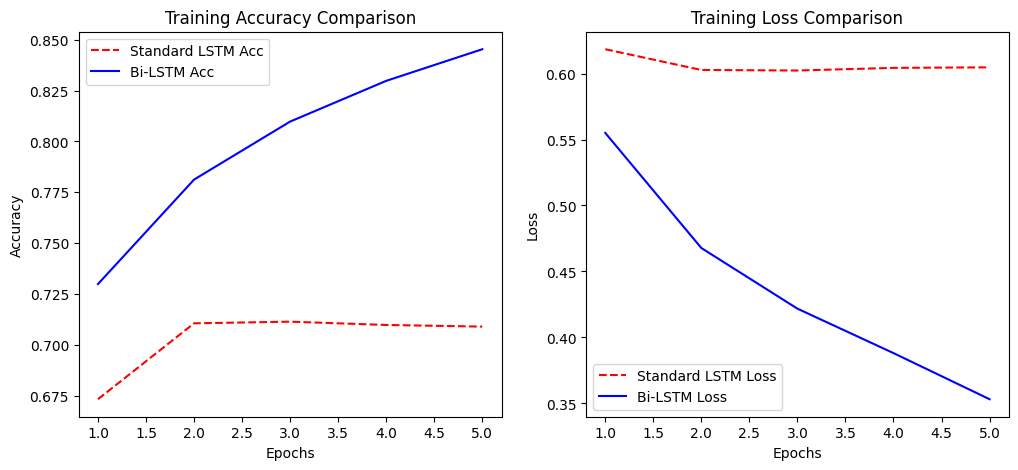

In [14]:
def plot_pytorch_comparison(lstm_hist, bilstm_hist):
    epochs = range(1, len(lstm_hist['acc']) + 1)

    plt.figure(figsize=(12, 5))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, lstm_hist['acc'], 'r--', label='Standard LSTM Acc')
    plt.plot(epochs, bilstm_hist['acc'], 'b-', label='Bi-LSTM Acc')
    plt.title('Training Accuracy Comparison')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, lstm_hist['loss'], 'r--', label='Standard LSTM Loss')
    plt.plot(epochs, bilstm_hist['loss'], 'b-', label='Bi-LSTM Loss')
    plt.title('Training Loss Comparison')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

plot_pytorch_comparison(lstm_history, bilstm_history)

In [22]:
from sklearn.metrics import classification_report
import numpy as np

def get_predictions(model, loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for text, labels in loader:
            text = text.to(device)
            # Use sigmoid because model outputs logits
            preds = torch.sigmoid(model(text).squeeze(1))
            all_preds.extend(torch.round(preds).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_labels, all_preds

y_true, y_pred = get_predictions(bilstm_model, test_loader)
print("\nDetailed Bi-LSTM Performance:")
print(classification_report(y_true, y_pred, target_names=['Negative', 'Positive']))


Detailed Bi-LSTM Performance:
              precision    recall  f1-score   support

    Negative       0.83      0.93      0.88      2364
    Positive       0.75      0.54      0.63       967

    accuracy                           0.81      3331
   macro avg       0.79      0.73      0.75      3331
weighted avg       0.81      0.81      0.80      3331



In [16]:
# Save the model
torch.save(bilstm_model.state_dict(), 'bilstm_sentiment_model.pt')



In [24]:

comparison_data = {
    'Model Architecture': ['Standard LSTM', 'Bidirectional LSTM'],
    'Test Accuracy (%)': [round(lstm_test_acc, 2), round(bilstm_test_acc, 2)],
    'Training Loss (Final)': [0.6027, 0.3604], # Extracted from  training output
     'Total Parameters': [sum(p.numel() for p in lstm_model.parameters()),
                   sum(p.numel() for p in bilstm_model.parameters())],
    'Accuracy Improvement': ['-', f"+{round(bilstm_test_acc - lstm_test_acc, 2)}%"]
}

# Create DataFrame
final_comparison_df = pd.DataFrame(comparison_data)

#display
print("--- Final Model Performance Comparison ---")
display(final_comparison_df)


--- Final Model Performance Comparison ---


,Model Architecture,Test Accuracy (%),Training Loss (Final),Total Parameters,Accuracy Improvement
0,Standard LSTM,71.49,0.6027,354929,-
1,Bidirectional LSTM,81.78,0.3604,389745,+10.29%
